In [1]:
import pandas as pd

# Path to churn dataset
file_path = r"D:\Data_Analyst_Projects\Customer_Retention_Intelligence\data\cleaned\customer_churn.csv"

# Load dataset
df_churn = pd.read_csv(file_path)

# Display first 5 rows
df_churn.head()

,customerid,recency_days,frequency,monetary,unique_products,lifespan_days,churn
0,12346,226,1,77183.60,1,0,1
1,12347,30,5,2790.86,82,238,0
2,12348,149,3,1487.24,22,110,0
3,12350,211,1,334.40,17,0,1
4,12352,163,5,1561.81,26,34,0


In [2]:
print("Rows:", df_churn.shape[0])
print("Columns:", df_churn.shape[1])

print("\nMissing values:")
print(df_churn.isnull().sum())

print("\nChurn distribution:")
print(df_churn["churn"].value_counts())

print("\nData types:")
print(df_churn.dtypes)

Rows: 3317
Columns: 7

Missing values:
customerid         0
recency_days       0
frequency          0
monetary           0
unique_products    0
lifespan_days      0
churn              0
dtype: int64

Churn distribution:
churn
0    1864
1    1453
Name: count, dtype: int64

Data types:
customerid           int64
recency_days         int64
frequency            int64
monetary           float64
unique_products      int64
lifespan_days        int64
churn                int64
dtype: object


In [3]:
# Select the columns that the ML model will use to make predictions
# These are customer behavior features calculated before the cutoff date
X = df_churn[
    [
        "recency_days",
        "frequency",
        "monetary",
        "unique_products",
        "lifespan_days"
    ]
]


# Select the column that we want the model to predict
# 0 = customer purchased again
# 1 = customer did not purchase in the next 90 days
y = df_churn["churn"]


# Display the first 5 rows of the input features
print("Features (X):")
print(X.head())


# Display the first 5 churn labels
print("\nTarget (y):")
print(y.head())

Features (X):
   recency_days  frequency  monetary  unique_products  lifespan_days
0           226          1  77183.60                1              0
1            30          5   2790.86               82            238
2           149          3   1487.24               22            110
3           211          1    334.40               17              0
4           163          5   1561.81               26             34

Target (y):
0    1
1    0
2    0
3    1
4    0
Name: churn, dtype: int64


In [4]:
# Check how many customer records and features we have
print("X shape:", X.shape)


# Check how many target values we have
print("y shape:", y.shape)

X shape: (3317, 5)
y shape: (3317,)


In [5]:
# Import train_test_split to divide the dataset into training and testing data
from sklearn.model_selection import train_test_split


# Split the features (X) and target (y)
# 80% of the data will be used for training
# 20% of the data will be used for testing
# random_state=42 makes the same split reproducible
# stratify=y keeps the churn/non-churn proportion similar in both datasets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# Display the number of records in each dataset
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (2653, 5)
Testing features: (664, 5)
Training target: (2653,)
Testing target: (664,)


In [6]:
# Import Logistic Regression for binary classification
from sklearn.linear_model import LogisticRegression


# Create the Logistic Regression model
# max_iter=1000 gives the model enough iterations to find a solution
model = LogisticRegression(max_iter=1000)


# Train the model using the training features and training churn labels
model.fit(X_train, y_train)


# Print a message to confirm that training is completed
print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [7]:
# Use the trained model to predict churn for the unseen test customers
y_pred = model.predict(X_test)


# Display the first 20 actual churn values
print("Actual values:")
print(y_test.head(20).values)


# Display the first 20 predictions made by the model
print("\nPredicted values:")
print(y_pred[:20])

Actual values:
[1 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0]

Predicted values:
[0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0]


In [8]:
# Import evaluation metrics for classification
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# Calculate how many predictions are correct overall
accuracy = accuracy_score(y_test, y_pred)


# Calculate precision
# Among customers predicted as churned, how many actually churned?
precision = precision_score(y_test, y_pred)


# Calculate recall
# Among customers who actually churned, how many did the model identify?
recall = recall_score(y_test, y_pred)


# Calculate F1-score
# F1 combines precision and recall into one metric
f1 = f1_score(y_test, y_pred)


# Display the evaluation metrics
print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))


# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# Display the complete classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy : 0.6687
Precision: 0.6149
Recall   : 0.6529
F1 Score : 0.6333

Confusion Matrix:
[[254 119]
 [101 190]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.68      0.70       373
           1       0.61      0.65      0.63       291

    accuracy                           0.67       664
   macro avg       0.67      0.67      0.67       664
weighted avg       0.67      0.67      0.67       664



In [9]:
# Create a table containing each feature and its Logistic Regression coefficient
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})


# Sort the features by their coefficient
# This helps us see which features have stronger positive or negative relationships with churn
feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)


# Display the feature coefficients
print(feature_importance)

           Feature  Coefficient
0     recency_days     0.003723
2         monetary     0.000009
4    lifespan_days    -0.002650
3  unique_products    -0.006192
1        frequency    -0.187818


In [10]:
# Import StandardScaler to put all features on a comparable scale
from sklearn.preprocessing import StandardScaler


# Create the scaler
scaler = StandardScaler()


# Learn the scaling values from the training data
# and transform the training features
X_train_scaled = scaler.fit_transform(X_train)


# Use the same scaling learned from the training data
# to transform the test features
X_test_scaled = scaler.transform(X_test)


# Display the shapes to confirm the transformation
print("Scaled training data:", X_train_scaled.shape)
print("Scaled testing data:", X_test_scaled.shape)

Scaled training data: (2653, 5)
Scaled testing data: (664, 5)


In [11]:
scaler.fit_transform(X_train)

array([[-6.35283384e-01, -2.47981925e-01, -1.89457385e-01,
        -4.01033402e-01,  3.84580587e-01],
       [-6.61301984e-01,  9.48503481e-01,  2.11542822e-01,
         1.98316598e+00,  1.58359081e+00],
       [-8.56441480e-01,  9.38710482e-02,  1.39601279e-01,
         3.45489399e+00,  1.36558895e+00],
       ...,
       [ 2.17230297e-03,  9.38710482e-02, -1.76985235e-01,
         1.14071403e-01,  9.18685140e-01],
       [-1.10361817e+00,  6.06650508e-01,  1.85049461e-01,
         6.88045328e-01,  1.99779434e+00],
       [-7.65376382e-01, -2.47981925e-01, -1.97363701e-01,
        -4.74619802e-01, -1.38623873e-01]], shape=(2653, 5))

In [12]:
scaler.transform(X_test)

array([[-0.67431128,  0.09387105,  0.12402931,  0.43785157, -0.08412341],
       [ 2.16171606, -0.41890841, -0.21875906, -0.57764076, -0.90163038],
       [-0.10190209, -0.41890841, -0.21382884, -0.51877164, -0.90163038],
       ...,
       [ 1.65435337, -0.41890841, -0.10019821, -0.57764076, -0.90163038],
       [ 1.19902788, -0.41890841, -0.23842909, -0.51877164, -0.90163038],
       [-1.18167397, -0.07705544,  0.36352035, -0.12140508,  1.22388774]],
      shape=(664, 5))

In [13]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression


# Create a new Logistic Regression model
# This model will use the standardized features
scaled_model = LogisticRegression(max_iter=1000)


# Train the model using the scaled training data
scaled_model.fit(X_train_scaled, y_train)


# Print a message to confirm that training is complete
print("Scaled Logistic Regression model trained successfully.")

Scaled Logistic Regression model trained successfully.


In [14]:
# Use the trained scaled model to predict churn
y_pred_scaled = scaled_model.predict(X_test_scaled)


# Display the first 20 predictions
print("Predicted values:")
print(y_pred_scaled[:20])

Predicted values:
[0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0]


In [15]:
# Import evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# Calculate accuracy of the scaled model
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)


# Calculate precision of the scaled model
precision_scaled = precision_score(y_test, y_pred_scaled)


# Calculate recall of the scaled model
recall_scaled = recall_score(y_test, y_pred_scaled)


# Calculate F1-score of the scaled model
f1_scaled = f1_score(y_test, y_pred_scaled)


# Display the evaluation results
print("Scaled Model Results")
print("--------------------")
print("Accuracy :", round(accuracy_scaled, 4))
print("Precision:", round(precision_scaled, 4))
print("Recall   :", round(recall_scaled, 4))
print("F1 Score :", round(f1_scaled, 4))


# Display the confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_scaled))

Scaled Model Results
--------------------
Accuracy : 0.6657
Precision: 0.6117
Recall   : 0.6495
F1 Score : 0.63

Confusion Matrix:
[[253 120]
 [102 189]]


In [16]:
# Create a table containing each feature and its standardized coefficient
scaled_feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": scaled_model.coef_[0]
})


# Sort the features from highest coefficient to lowest coefficient
scaled_feature_importance = scaled_feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)


# Display the feature importance table
print("Feature Importance from Scaled Logistic Regression:")
print(scaled_feature_importance)

Feature Importance from Scaled Logistic Regression:
           Feature  Coefficient
0     recency_days     0.286350
2         monetary     0.050038
4    lifespan_days    -0.254028
3  unique_products    -0.420757
1        frequency    -1.053620


In [17]:
# Import the ROC-AUC metric
from sklearn.metrics import roc_auc_score


# Get the probability of churn (class 1) for each test customer
y_prob = scaled_model.predict_proba(X_test_scaled)[:, 1]


# Calculate the ROC-AUC score
roc_auc = roc_auc_score(y_test, y_prob)


# Display the ROC-AUC score
print("ROC-AUC Score:", round(roc_auc, 4))

ROC-AUC Score: 0.7307


In [18]:
# Import the Random Forest classification algorithm
from sklearn.ensemble import RandomForestClassifier


# Create the Random Forest model
# random_state=42 makes the result reproducible
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)


# Train the Random Forest using the original training data
rf_model.fit(X_train, y_train)


# Confirm that the model has been trained
print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [19]:
# Predict churn classes for the test data
rf_pred = rf_model.predict(X_test)

# Predict churn probabilities for ROC-AUC
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Display the first 20 predicted classes
print("Predicted values:")
print(rf_pred[:20])

# Display the first 20 churn probabilities
print("\nPredicted probabilities:")
print(rf_prob[:20])

Predicted values:
[0 1 1 0 0 0 0 1 1 0 0 1 0 1 0 0 1 0 1 0]

Predicted probabilities:
[0.23  0.615 0.66  0.135 0.215 0.005 0.38  0.575 0.74  0.155 0.475 0.745
 0.365 0.865 0.295 0.14  0.53  0.4   0.595 0.345]


In [20]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC for Random Forest
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_auc)

Random Forest ROC-AUC: 0.6956275393162158


In [21]:
# Compare the ROC-AUC scores of both models

logistic_auc = 0.7307

print("Model Comparison")
print("----------------")
print("Logistic Regression ROC-AUC:", logistic_auc)
print("Random Forest ROC-AUC:", rf_auc)

Model Comparison
----------------
Logistic Regression ROC-AUC: 0.7307
Random Forest ROC-AUC: 0.6956275393162158


In [22]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for Random Forest
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print("Random Forest Metrics")
print("---------------------")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1-Score :", rf_f1)

Random Forest Metrics
---------------------
Accuracy : 0.6355421686746988
Precision: 0.5830508474576271
Recall   : 0.5910652920962199
F1-Score : 0.5870307167235495


In [23]:
# Compare Logistic Regression and Random Forest

comparison = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        0.7307
    ],
    "Random Forest": [
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1,
        rf_auc
    ]
}

comparison_df = pd.DataFrame(comparison)

print(comparison_df)


      Metric  Logistic Regression  Random Forest
0   Accuracy             0.668675       0.635542
1  Precision             0.614887       0.583051
2     Recall             0.652921       0.591065
3   F1-Score             0.633333       0.587031
4    ROC-AUC             0.730700       0.695628


In [24]:
from sklearn.metrics import confusion_matrix

# Confusion matrix for Logistic Regression
lr_cm = confusion_matrix(y_test, y_pred)

# Confusion matrix for Random Forest
rf_cm = confusion_matrix(y_test, rf_pred)

print("Logistic Regression Confusion Matrix:")
print(lr_cm)

print("\nRandom Forest Confusion Matrix:")
print(rf_cm)

Logistic Regression Confusion Matrix:
[[254 119]
 [101 190]]

Random Forest Confusion Matrix:
[[250 123]
 [119 172]]


Logistic Regression Confusion Matrix:

[[TN FP]

 [FN TP]]

Random Forest Confusion Matrix:

[[TN FP]

 [FN TP]]

TN → correctly predicted non-churn customers

FP → predicted churn, but customer didn't churn

FN → predicted non-churn, but customer actually churned

TP → correctly predicted churn customers

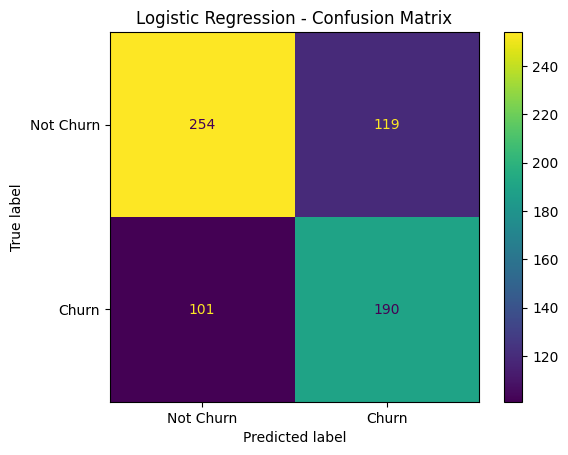

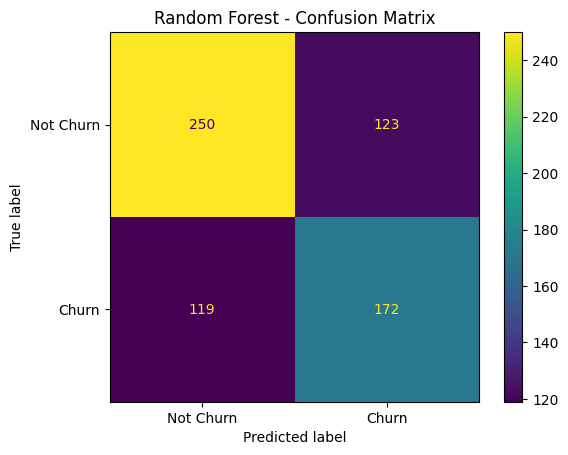

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Not Churn", "Churn"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()


# Random Forest confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_pred,
    display_labels=["Not Churn", "Churn"]
)

plt.title("Random Forest - Confusion Matrix")
plt.show()

In [26]:
# Get feature importance from Random Forest
rf_importance = rf_model.feature_importances_

# Create a DataFrame
rf_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_importance
})

# Sort from highest to lowest importance
rf_feature_importance = rf_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
print(rf_feature_importance)

Random Forest Feature Importance:
           Feature  Importance
2         monetary    0.303008
0     recency_days    0.247116
3  unique_products    0.199037
4    lifespan_days    0.171339
1        frequency    0.079501


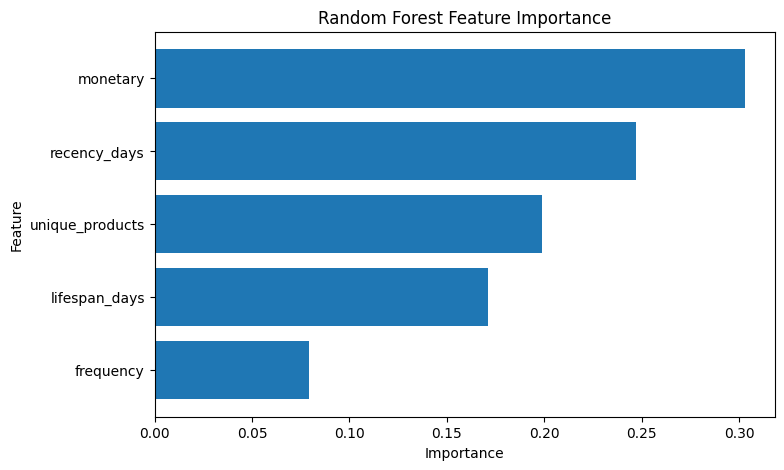

In [27]:
# Plot Random Forest feature importance

plt.figure(figsize=(8, 5))

plt.barh(
    rf_feature_importance["Feature"],
    rf_feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

# Show most important feature at the top
plt.gca().invert_yaxis()

plt.show()

In [28]:
n_estimators=200

In [29]:
from sklearn.model_selection import GridSearchCV

# Define different Random Forest settings to test
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Create a Random Forest for tuning
rf_tuning = RandomForestClassifier(
    random_state=42
)

# Grid Search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

# Train and test all parameter combinations
grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best Cross-Validation ROC-AUC:
0.7457221292665281


In [30]:
# Create the tuned Random Forest model
best_rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)

# Train the tuned model
best_rf_model.fit(X_train, y_train)

print("Tuned Random Forest trained successfully.")

Tuned Random Forest trained successfully.


In [31]:
# Predict churn classes
best_rf_pred = best_rf_model.predict(X_test)

# Predict churn probabilities
best_rf_prob = best_rf_model.predict_proba(X_test)[:, 1]

print("Tuned Random Forest predictions:")
print(best_rf_pred[:20])

print("\nTuned Random Forest probabilities:")
print(best_rf_prob[:20])


Tuned Random Forest predictions:
[0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0]

Tuned Random Forest probabilities:
[0.20588196 0.66877222 0.56302616 0.21378208 0.26637607 0.03831354
 0.61068311 0.61456153 0.66658785 0.10274144 0.3716616  0.66409657
 0.354597   0.69279284 0.21903767 0.22290994 0.66717323 0.30165535
 0.37890776 0.25781921]


In [32]:
from sklearn.metrics import roc_auc_score

# Calculate ROC-AUC for the tuned Random Forest
best_rf_auc = roc_auc_score(y_test, best_rf_prob)

print("Tuned Random Forest ROC-AUC:", best_rf_auc)

Tuned Random Forest ROC-AUC: 0.7357913453654312


In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for tuned Random Forest
best_rf_accuracy = accuracy_score(y_test, best_rf_pred)
best_rf_precision = precision_score(y_test, best_rf_pred)
best_rf_recall = recall_score(y_test, best_rf_pred)
best_rf_f1 = f1_score(y_test, best_rf_pred)

print("Tuned Random Forest Metrics")
print("---------------------------")
print("Accuracy :", best_rf_accuracy)
print("Precision:", best_rf_precision)
print("Recall   :", best_rf_recall)
print("F1-Score :", best_rf_f1)
print("ROC-AUC  :", best_rf_auc)

Tuned Random Forest Metrics
---------------------------
Accuracy : 0.6671686746987951
Precision: 0.6080246913580247
Recall   : 0.6769759450171822
F1-Score : 0.640650406504065
ROC-AUC  : 0.7357913453654312


In [34]:
# Final comparison of all three models

final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        rf_accuracy,
        best_rf_accuracy
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        rf_precision,
        best_rf_precision
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        rf_recall,
        best_rf_recall
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        rf_f1,
        best_rf_f1
    ],
    "ROC-AUC": [
        0.7307,
        rf_auc,
        best_rf_auc
    ]
})

print(final_comparison.round(4))

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.6687     0.6149  0.6529    0.6333   0.7307
1        Random Forest    0.6355     0.5831  0.5911    0.5870   0.6956
2  Tuned Random Forest    0.6672     0.6080  0.6770    0.6407   0.7358


In [35]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
best_rf_cm = confusion_matrix(y_test, best_rf_pred)

print("Tuned Random Forest Confusion Matrix:")
print(best_rf_cm)

Tuned Random Forest Confusion Matrix:
[[246 127]
 [ 94 197]]


In [36]:
import joblib

joblib.dump(best_rf_model, "customer_churn_model.pkl")

print("Final model saved successfully.")

Final model saved successfully.


In [37]:
import joblib

loaded_model = joblib.load("customer_churn_model.pkl")

loaded_pred = loaded_model.predict(X_test)

print("Model loaded successfully.")
print("Predictions:")
print(loaded_pred)


Model loaded successfully.
Predictions:
[0 1 1 0 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 0 0 1 1 0 1 1 0 1 0 0 1 1 0 1 0 0 0
 1 0 0 1 0 1 1 1 1 0 0 0 0 1 1 1 1 1 0 0 1 1 0 1 1 1 1 0 0 0 0 1 0 0 0 1 1
 0 1 1 1 1 0 1 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 1 1 0 0 1 1 0 1 1 1 0 1 0 0
 0 1 0 1 0 1 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 0 1 1 1 1 0 0 0 0 0 0
 0 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 0 1 1 0 0 1 0 0 1 1 0 1 0 1 0 1 1 0 0 0 0
 0 0 0 0 1 1 1 0 1 1 1 0 0 0 0 1 0 0 0 1 1 1 0 0 1 0 1 0 0 0 0 0 0 1 1 0 0
 0 0 0 1 1 1 1 0 1 1 1 1 1 1 0 1 0 1 0 0 0 0 1 1 1 1 0 1 1 1 0 1 0 0 0 1 0
 0 1 1 0 1 1 0 1 1 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1 1 0 1 0 1 0 1 1 0 1 0 1 0
 0 0 0 1 1 0 0 0 0 1 1 0 0 1 1 1 1 0 0 0 1 1 1 0 1 1 1 1 0 1 1 1 0 0 0 0 1
 0 0 0 1 0 0 1 0 1 1 0 0 1 0 0 1 1 1 1 1 0 0 0 1 0 1 1 1 1 1 1 1 1 1 1 0 0
 0 0 1 0 0 1 0 0 0 1 0 0 1 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 1 1 0 0 0 0 1 1 0
 0 1 0 0 1 0 0 0 0 0 1 0 0 1 0 1 0 0 1 0 0 0 0 0 1 0 1 1 0 1 0 1 1 1 1 1 0
 0 0 0 0 1 1 1 0 1 1 0 0 0 1 0 0 0 0 1 0 0 1 1 1 0 1 1 0 1 1

In [38]:
from sklearn.metrics import accuracy_score

loaded_accuracy = accuracy_score(y_test, loaded_pred)

print("Loaded Model Accuracy:", loaded_accuracy)

Loaded Model Accuracy: 0.6671686746987951


In [39]:
final_model_summary = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Tuned Random Forest"
    ],
    "Accuracy": [
        0.6687,
        0.6355,
        0.6672
    ],
    "Precision": [
        0.6149,
        0.5831,
        0.6080
    ],
    "Recall": [
        0.6529,
        0.5911,
        0.6770
    ],
    "F1-Score": [
        0.6333,
        0.5870,
        0.6407
    ],
    "ROC-AUC": [
        0.7307,
        0.6956,
        0.7358
    ]
})

print(final_model_summary)

                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0  Logistic Regression    0.6687     0.6149  0.6529    0.6333   0.7307
1        Random Forest    0.6355     0.5831  0.5911    0.5870   0.6956
2  Tuned Random Forest    0.6672     0.6080  0.6770    0.6407   0.7358


In [40]:
churn_probability = best_rf_model.predict_proba(X_test)[:, 1]

high_risk_customers = X_test.copy()
high_risk_customers["churn_probability"] = churn_probability

high_risk_customers = high_risk_customers.sort_values(
    by="churn_probability",
    ascending=False
)

print("Top 10 High-Risk Customers:")
print(high_risk_customers.head(10))

Top 10 High-Risk Customers:
      recency_days  frequency  monetary  unique_products  lifespan_days  \
994            225          1     76.32                1              0   
3191           190          1    101.70                1              0   
3184           260          1     74.40                5              0   
1385           235          1     97.50                7              0   
3121           147          1     78.26               17              0   
1931           147          1     91.80                6              0   
2492           175          1     93.18                5              0   
3163           182          1     76.10                2              0   
2345           266          1    103.70                5              0   
3042           218          1    103.35               24              0   

      churn_probability  
994            0.805451  
3191           0.796114  
3184           0.792041  
1385           0.791355  
3121           0

In [41]:
high_risk = high_risk_customers[
    high_risk_customers["churn_probability"] >= 0.70
]

print("Number of High-Risk Customers:", len(high_risk))

print("\nAverage High-Risk Customer Characteristics:")
print(
    high_risk[
        [
            "recency_days",
            "frequency",
            "monetary",
            "unique_products",
            "lifespan_days"
        ]
    ].mean()
)

Number of High-Risk Customers: 27

Average High-Risk Customer Characteristics:
recency_days       184.037037
frequency            1.111111
monetary           214.096296
unique_products      5.037037
lifespan_days        0.666667
dtype: float64


In [42]:
def risk_category(probability):
    if probability >= 0.70:
        return "High Risk"
    elif probability >= 0.40:
        return "Medium Risk"
    else:
        return "Low Risk"


high_risk_customers["risk_category"] = (
    high_risk_customers["churn_probability"]
    .apply(risk_category)
)

print(
    high_risk_customers[
        ["churn_probability", "risk_category"]
    ].head(20)
)

      churn_probability risk_category
994            0.805451     High Risk
3191           0.796114     High Risk
3184           0.792041     High Risk
1385           0.791355     High Risk
3121           0.789674     High Risk
1931           0.789558     High Risk
2492           0.789237     High Risk
3163           0.774428     High Risk
2345           0.773327     High Risk
3042           0.762137     High Risk
881            0.762129     High Risk
2291           0.762103     High Risk
1756           0.759798     High Risk
3037           0.753587     High Risk
2240           0.750038     High Risk
2704           0.749124     High Risk
3029           0.726807     High Risk
2667           0.726149     High Risk
1143           0.722422     High Risk
1609           0.713166     High Risk


In [43]:
risk_counts = high_risk_customers["risk_category"].value_counts()

print("Customer Risk Distribution:")
print(risk_counts)

Customer Risk Distribution:
risk_category
Medium Risk    375
Low Risk       262
High Risk       27
Name: count, dtype: int64


In [44]:
risk_percentage = (
    high_risk_customers["risk_category"]
    .value_counts(normalize=True)
    * 100
)

print("Customer Risk Distribution (%):")
print(risk_percentage.round(2))

Customer Risk Distribution (%):
risk_category
Medium Risk    56.48
Low Risk       39.46
High Risk       4.07
Name: proportion, dtype: float64


In [45]:
final_importance = best_rf_model.feature_importances_

final_feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": final_importance
})

final_feature_importance = final_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Final Model Feature Importance:")
print(final_feature_importance)

Final Model Feature Importance:
           Feature  Importance
4    lifespan_days    0.296060
2         monetary    0.246762
1        frequency    0.203170
0     recency_days    0.143207
3  unique_products    0.110802


In [46]:
business_insights = pd.DataFrame({
    "Insight": [
        "High-risk customers identified",
        "High-risk customer average recency",
        "High-risk customer average frequency",
        "High-risk customer average spending",
        "High-risk customer average lifespan"
    ],
    "Value": [
        len(high_risk),
        round(high_risk["recency_days"].mean(), 2),
        round(high_risk["frequency"].mean(), 2),
        round(high_risk["monetary"].mean(), 2),
        round(high_risk["lifespan_days"].mean(), 2)
    ]
})

print("Final Business Insights:")
print(business_insights)

Final Business Insights:
                                Insight   Value
0        High-risk customers identified   27.00
1    High-risk customer average recency  184.04
2  High-risk customer average frequency    1.11
3   High-risk customer average spending  214.10
4   High-risk customer average lifespan    0.67


In [47]:
def retention_action(risk):
    if risk == "High Risk":
        return "Immediate re-engagement offer"
    elif risk == "Medium Risk":
        return "Personalized recommendation"
    else:
        return "Regular engagement"

high_risk_customers["retention_action"] = (
    high_risk_customers["risk_category"]
    .apply(retention_action)
)

print(
    high_risk_customers[
        ["churn_probability", "risk_category", "retention_action"]
    ].head(20)
)

      churn_probability risk_category               retention_action
994            0.805451     High Risk  Immediate re-engagement offer
3191           0.796114     High Risk  Immediate re-engagement offer
3184           0.792041     High Risk  Immediate re-engagement offer
1385           0.791355     High Risk  Immediate re-engagement offer
3121           0.789674     High Risk  Immediate re-engagement offer
1931           0.789558     High Risk  Immediate re-engagement offer
2492           0.789237     High Risk  Immediate re-engagement offer
3163           0.774428     High Risk  Immediate re-engagement offer
2345           0.773327     High Risk  Immediate re-engagement offer
3042           0.762137     High Risk  Immediate re-engagement offer
881            0.762129     High Risk  Immediate re-engagement offer
2291           0.762103     High Risk  Immediate re-engagement offer
1756           0.759798     High Risk  Immediate re-engagement offer
3037           0.753587     High R

In [48]:
final_customer_risk = high_risk_customers.copy()

final_customer_risk.to_csv(
    "customer_churn_risk_results.csv",
    index=True
)

print("Customer risk results saved successfully.")
print("File: customer_churn_risk_results.csv")

Customer risk results saved successfully.
File: customer_churn_risk_results.csv


In [49]:
print("FINAL PROJECT VALIDATION")
print("------------------------")

print("Final Model:", type(best_rf_model).__name__)
print("Test Accuracy:", round(loaded_accuracy, 4))
print("Test ROC-AUC:", round(0.7357913453654312, 4))

print("High-Risk Customers:", len(high_risk))
print("Total Test Customers:", len(high_risk_customers))

print("\nSaved Files:")
print("1. customer_churn_model.pkl")
print("2. customer_churn_risk_results.csv")


FINAL PROJECT VALIDATION
------------------------
Final Model: RandomForestClassifier
Test Accuracy: 0.6672
Test ROC-AUC: 0.7358
High-Risk Customers: 27
Total Test Customers: 664

Saved Files:
1. customer_churn_model.pkl
2. customer_churn_risk_results.csv
